# Ranking claim documents — the algorithm behind the review queue

**Knowledge-Engineering case study · openIMIS Nepal (Health Insurance Board and Social Security Fund) · Week 5**
Grishma Rijal · Rijan Ghimire · Milan Maharjan · Biwash Budhathoki

This notebook isolates **the algorithm that separates and ranks claim documents** from the Claim Journey web app, so it can be
read, run and changed on its own. The code in `claim_ranking.py` is a line-for-line port of the app's engine
(`Week 3-4/mvp/backend/engine/{existing.js, rules.js, store.js}`) and reproduces the app's numbers exactly.

> **All claims are synthetic.** They were generated by `Week 3-4/synthetic_data/nepal_synthetic_claims.py` (training book, seed 42)
> and `nepal_validation_book.py` (independent validation book, seed 2026). There is no real patient or claim data anywhere in this project.

**Dataset location** (copies of the app's books, so this folder is self-contained):

| File | What | Origin |
|---|---|---|
| `data/claims_training.json` | 9,786 synthetic claims, 454 with planted fraud — the book the rules were developed on | `Week 3-4/synthetic_data/out/claims.json` = `Week 3-4/mvp/backend/data/claims.json` |
| `data/claims_validation.json` | 6,825 synthetic claims, 261 with planted fraud — behaviour-based, written without the rules' thresholds | `Week 3-4/synthetic_data/out_validation/claims.json` = `Week 3-4/mvp/backend/data/validation.json` |
| `data/evaluation_from_app.json` | the app's own evaluation output, for cross-checking | `Week 3-4/mvp/backend/data/evaluation.json` (written by `node evaluate.js`) |

CSV versions of the same books (claims, claim lines, insurees, facilities) are in `Week 3-4/synthetic_data/out/` and `out_validation/`.

In [1]:
%matplotlib inline
import json, os, sys, time, inspect
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

sys.path.insert(0, os.path.abspath('.'))
import claim_ranking as cr
from claim_ranking import Engine, Params, RULES, FRAUD, evaluate, precision_at, is_fraud

NAVY, TEAL, TEAL2, GOLD, RED, MUTE = '#1f3864', '#0f9d8f', '#0c7d72', '#b8791f', '#c0392b', '#6b7280'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.titleweight': 'bold',
                     'axes.titlecolor': NAVY, 'axes.labelcolor': '#1f2a37', 'font.size': 9.5})
pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 200)

os.makedirs('figures', exist_ok=True)
BOOKS = {'A · training book (seed 42)': cr.data_path('training'), 'B · validation book (seed 2026)': cr.data_path('validation')}
raw = {k: cr.load_book(v) for k, v in BOOKS.items()}
for k, d in raw.items():
    print(f"{k}: {len(d['claims']):,} claims · {len(d['persons']):,} persons · {len(d['facilities'])} facilities · generator {d['meta']['generator']}")

A · training book (seed 42): 9,786 claims · 8,037 persons · 440 facilities · generator nepal_synthetic_claims.py
B · validation book (seed 2026): 6,825 claims · 5,589 persons · 440 facilities · generator nepal_validation_book.py (behaviour-based, independent of the rules)


## 1 · The dataset

Each claim carries the fields openIMIS stores (scheme, member number, facility, care type, dates, ICD-10 diagnosis, price-list lines,
the treating doctor's NMC number) plus two fields that exist only because the data is synthetic: `truth` (the fraud type the generator planted,
or `legitimate`) and `note` (why). Those two are the ground truth the algorithm is scored against; the algorithm never reads them.

In [2]:
def frame(d):
    df = pd.DataFrame(d['claims'])
    price = d['price_list']
    df['amount'] = df['lines'].map(lambda ls: sum(price.get(l['code'], 0) * l['qty'] for l in ls))
    df['n_lines'] = df['lines'].map(len)
    df['date_from'] = pd.to_datetime(df['date_from']); df['date_to'] = pd.to_datetime(df['date_to'].fillna(df['date_from']))
    df['los'] = (df['date_to'] - df['date_from']).dt.days
    df['fraud'] = df['truth'].isin(FRAUD)
    df['has_nid'] = df['national_id'].notna()
    return df

dfs = {k: frame(d) for k, d in raw.items()}
persons = {k: pd.DataFrame(d['persons']) for k, d in raw.items()}
rows = []
for k, df in dfs.items():
    p = persons[k]
    rows.append({'book': k, 'claims': len(df), 'persons': len(p), 'facilities': df.facility_id.nunique(),
                 'HIB claims': (df.scheme == 'HIB').sum(), 'SSF claims': (df.scheme == 'SSF').sum(),
                 'inpatient %': round(100 * (df.care_type == 'I').mean(), 1), 'persons with National ID %': round(100 * p.national_id.notna().mean(), 1),
                 'dual-enrolled persons': int((p.hib_id.notna() & p.ssf_id.notna()).sum()),
                 'median claim NPR': int(df.amount.median()), 'total claimed NPR (M)': round(df.amount.sum() / 1e6, 1),
                 'planted frauds': int(df.fraud.sum()), 'fraud rate %': round(100 * df.fraud.mean(), 2),
                 'first date': df.date_from.min().date(), 'last date': df.date_from.max().date()})
pd.DataFrame(rows).set_index('book').T

book,A · training book (seed 42),B · validation book (seed 2026)
claims,9786,6825
persons,8037,5589
facilities,440,440
HIB claims,9259,6387
SSF claims,527,438
inpatient %,13.8,14.6
persons with National ID %,43.2,43.5
dual-enrolled persons,654,506
median claim NPR,800,800
total claimed NPR (M),40.9,28.7


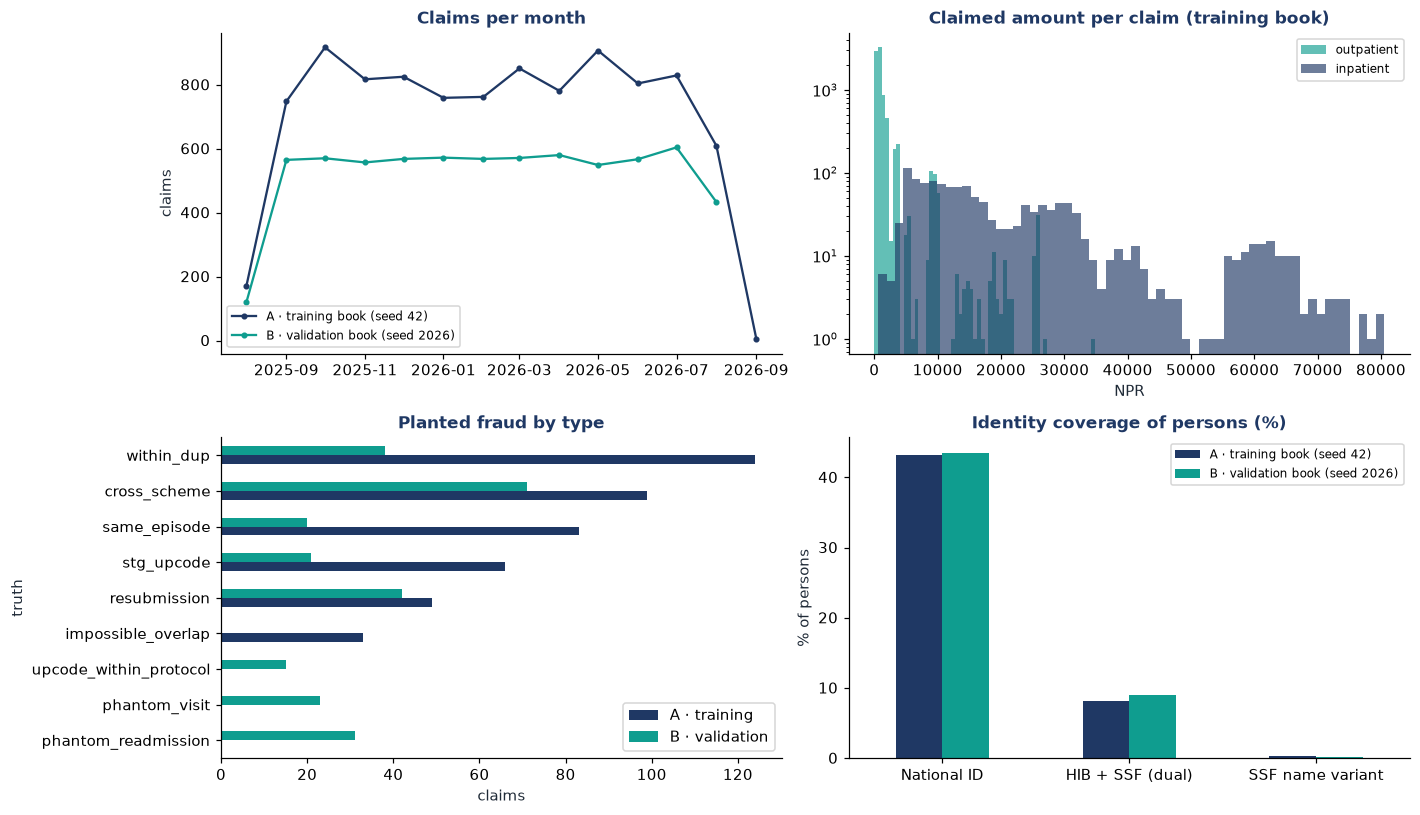

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
# claims per month, both schemes
ax = axes[0, 0]
for k, df in dfs.items():
    m = df.groupby(df.date_from.dt.to_period('M')).size()
    ax.plot(m.index.to_timestamp(), m.values, marker='o', ms=3, label=k, color=NAVY if k.startswith('A') else TEAL)
ax.set_title('Claims per month'); ax.legend(fontsize=8); ax.set_ylabel('claims')
# amount distribution
ax = axes[0, 1]; df = dfs['A · training book (seed 42)']
for ct, col, lab in [('O', TEAL, 'outpatient'), ('I', NAVY, 'inpatient')]:
    ax.hist(df[df.care_type == ct].amount, bins=60, alpha=.65, color=col, label=lab)
ax.set_title('Claimed amount per claim (training book)'); ax.set_xlabel('NPR'); ax.set_yscale('log'); ax.legend(fontsize=8)
# fraud types
ax = axes[1, 0]
ft = pd.concat({k: df[df.fraud].truth.value_counts() for k, df in dfs.items()}, axis=1).fillna(0).astype(int)
ft.columns = ['A · training', 'B · validation']
ft.sort_values('A · training').plot.barh(ax=ax, color=[NAVY, TEAL]); ax.set_title('Planted fraud by type'); ax.set_xlabel('claims')
# identity coverage
ax = axes[1, 1]
cov = pd.DataFrame({k: {'National ID': p.national_id.notna().mean(), 'HIB + SSF (dual)': (p.hib_id.notna() & p.ssf_id.notna()).mean(),
                        'SSF name variant': p.ssf_name_variant.notna().mean() if 'ssf_name_variant' in p else np.nan} for k, p in persons.items()}) * 100
cov.plot.bar(ax=ax, color=[NAVY, TEAL], rot=0); ax.set_title('Identity coverage of persons (%)'); ax.set_ylabel('% of persons'); ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig('figures/fig_dataset.png', dpi=150, bbox_inches='tight'); plt.show()

In [4]:
# the two things the algorithm reads besides the claim: the price list and the treatment protocols
d = raw['A · training book (seed 42)']
print(f"{len(d['price_list'])} price-list items, e.g.", dict(list(d['price_list'].items())[:6]))
proto = pd.DataFrame([{'dx': k, 'label': v['label'], 'allowed services': ', '.join(v['allow']), 'max LOS': v['max_los'], 'IPD share': v['ipd']} for k, v in d['protocol'].items()])
print(f"{len(proto)} standard treatment protocols (elicited from the HIB expert interview):")
proto.head(8)

30 price-list items, e.g. {'CONS-OPD': 200, 'CONS-SPEC': 500, 'LAB-CBC': 300, 'LAB-HBA1C': 900, 'LAB-RFT': 600, 'LAB-LFT': 700}
24 standard treatment protocols (elicited from the HIB expert interview):


,dx,label,allowed services,max LOS,IPD share
0,J06,Acute upper respiratory infection,"CONS-OPD, DRUGS-OPD, LAB-CBC, WARD-DAY, DRUGS-IPD, IV-FLUIDS, OXYGEN-DAY",1,0.02
1,A09,Gastroenteritis / diarrhoea,"CONS-OPD, DRUGS-OPD, IV-FLUIDS, LAB-URINE, WARD-DAY, DRUGS-IPD, OXYGEN-DAY",3,0.10
2,K29,Gastritis,"CONS-OPD, DRUGS-OPD, USG, WARD-DAY, DRUGS-IPD, IV-FLUIDS, OXYGEN-DAY",1,0.02
3,I10,Hypertension,"CONS-OPD, DRUGS-OPD, ECG, LAB-RFT, WARD-DAY, DRUGS-IPD, IV-FLUIDS, OXYGEN-DAY",2,0.03
4,E11,Type-2 diabetes,"CONS-OPD, DRUGS-OPD, LAB-HBA1C, LAB-RFT, WARD-DAY, DRUGS-IPD, IV-FLUIDS, OXYGEN-DAY",3,0.04
5,J45,Asthma,"CONS-OPD, DRUGS-OPD, NEBULIZATION, XRAY, OXYGEN-DAY, WARD-DAY, DRUGS-IPD, IV-FLUIDS",4,0.10
6,J44,COPD,"CONS-OPD, DRUGS-OPD, NEBULIZATION, XRAY, OXYGEN-DAY, WARD-DAY, ICU-DAY, DRUGS-IPD, IV-FLUIDS",7,0.25
7,N39,Urinary tract infection,"CONS-OPD, DRUGS-OPD, LAB-URINE, USG, WARD-DAY, DRUGS-IPD, IV-FLUIDS, OXYGEN-DAY",2,0.05


## 2 · The algorithm

Every claim is processed **once, in submission order**, and is then part of the history the next claim is compared against.

1. **Engine 1 — the openIMIS edits.** The real `validate_claim` checks, per claim in isolation: dates (9), coverage (21), price list (2), care type (10), quantity (16).
   Reason 6 *duplicated* and reason 8 *ICD not in list* are commented out in the openIMIS source, so no duplicate or diagnosis check exists today.
2. **Identity resolution.** National ID if the person has one, otherwise `name + date of birth + sex`. The same key is used for HIB and SSF, which is what lets the layer see across schemes.
3. **Claim history and provider context.** Every earlier claim of that identity (both schemes, all facilities, rejected ones included), the facility's rolling flag rate (last 100 claims) and the doctor's recent claims (by NMC number).
4. **Rules.** R1–R5 compare the claim with each earlier claim; R8 and STG look at the claim itself; R7 at the doctor; R6 at the facility. Each hit is a *flag* with a weight (high 3 / medium 2 / low 1) and a "because" sentence for the reviewer.
5. **Scoring.** An R4 overlap on the same matched claim as an R3 cross-scheme hit is the same event seen twice and gets 0 points (subsumption). `points = learned weight × confidence` (an R3 on a composite identity counts as medium). `suspicion = Σ points`.
6. **Routing.** Any flag → review status *Selected*; none → clean, valuated and paid.
7. **Ranking.** The queue is sorted by suspicion (ties in submission order). The reviewer budget is 5 % of the book, the size of today's random sample.
8. **Learning.** Confirm moves every rule that fired +0.5, clear −0.5 (bounded 0.5 … 5); release leaves the weights alone.

It is a **weighted additive rule model** (a scorecard), not a trained classifier: every point on a claim can be traced to a rule, a matched claim and a sentence.

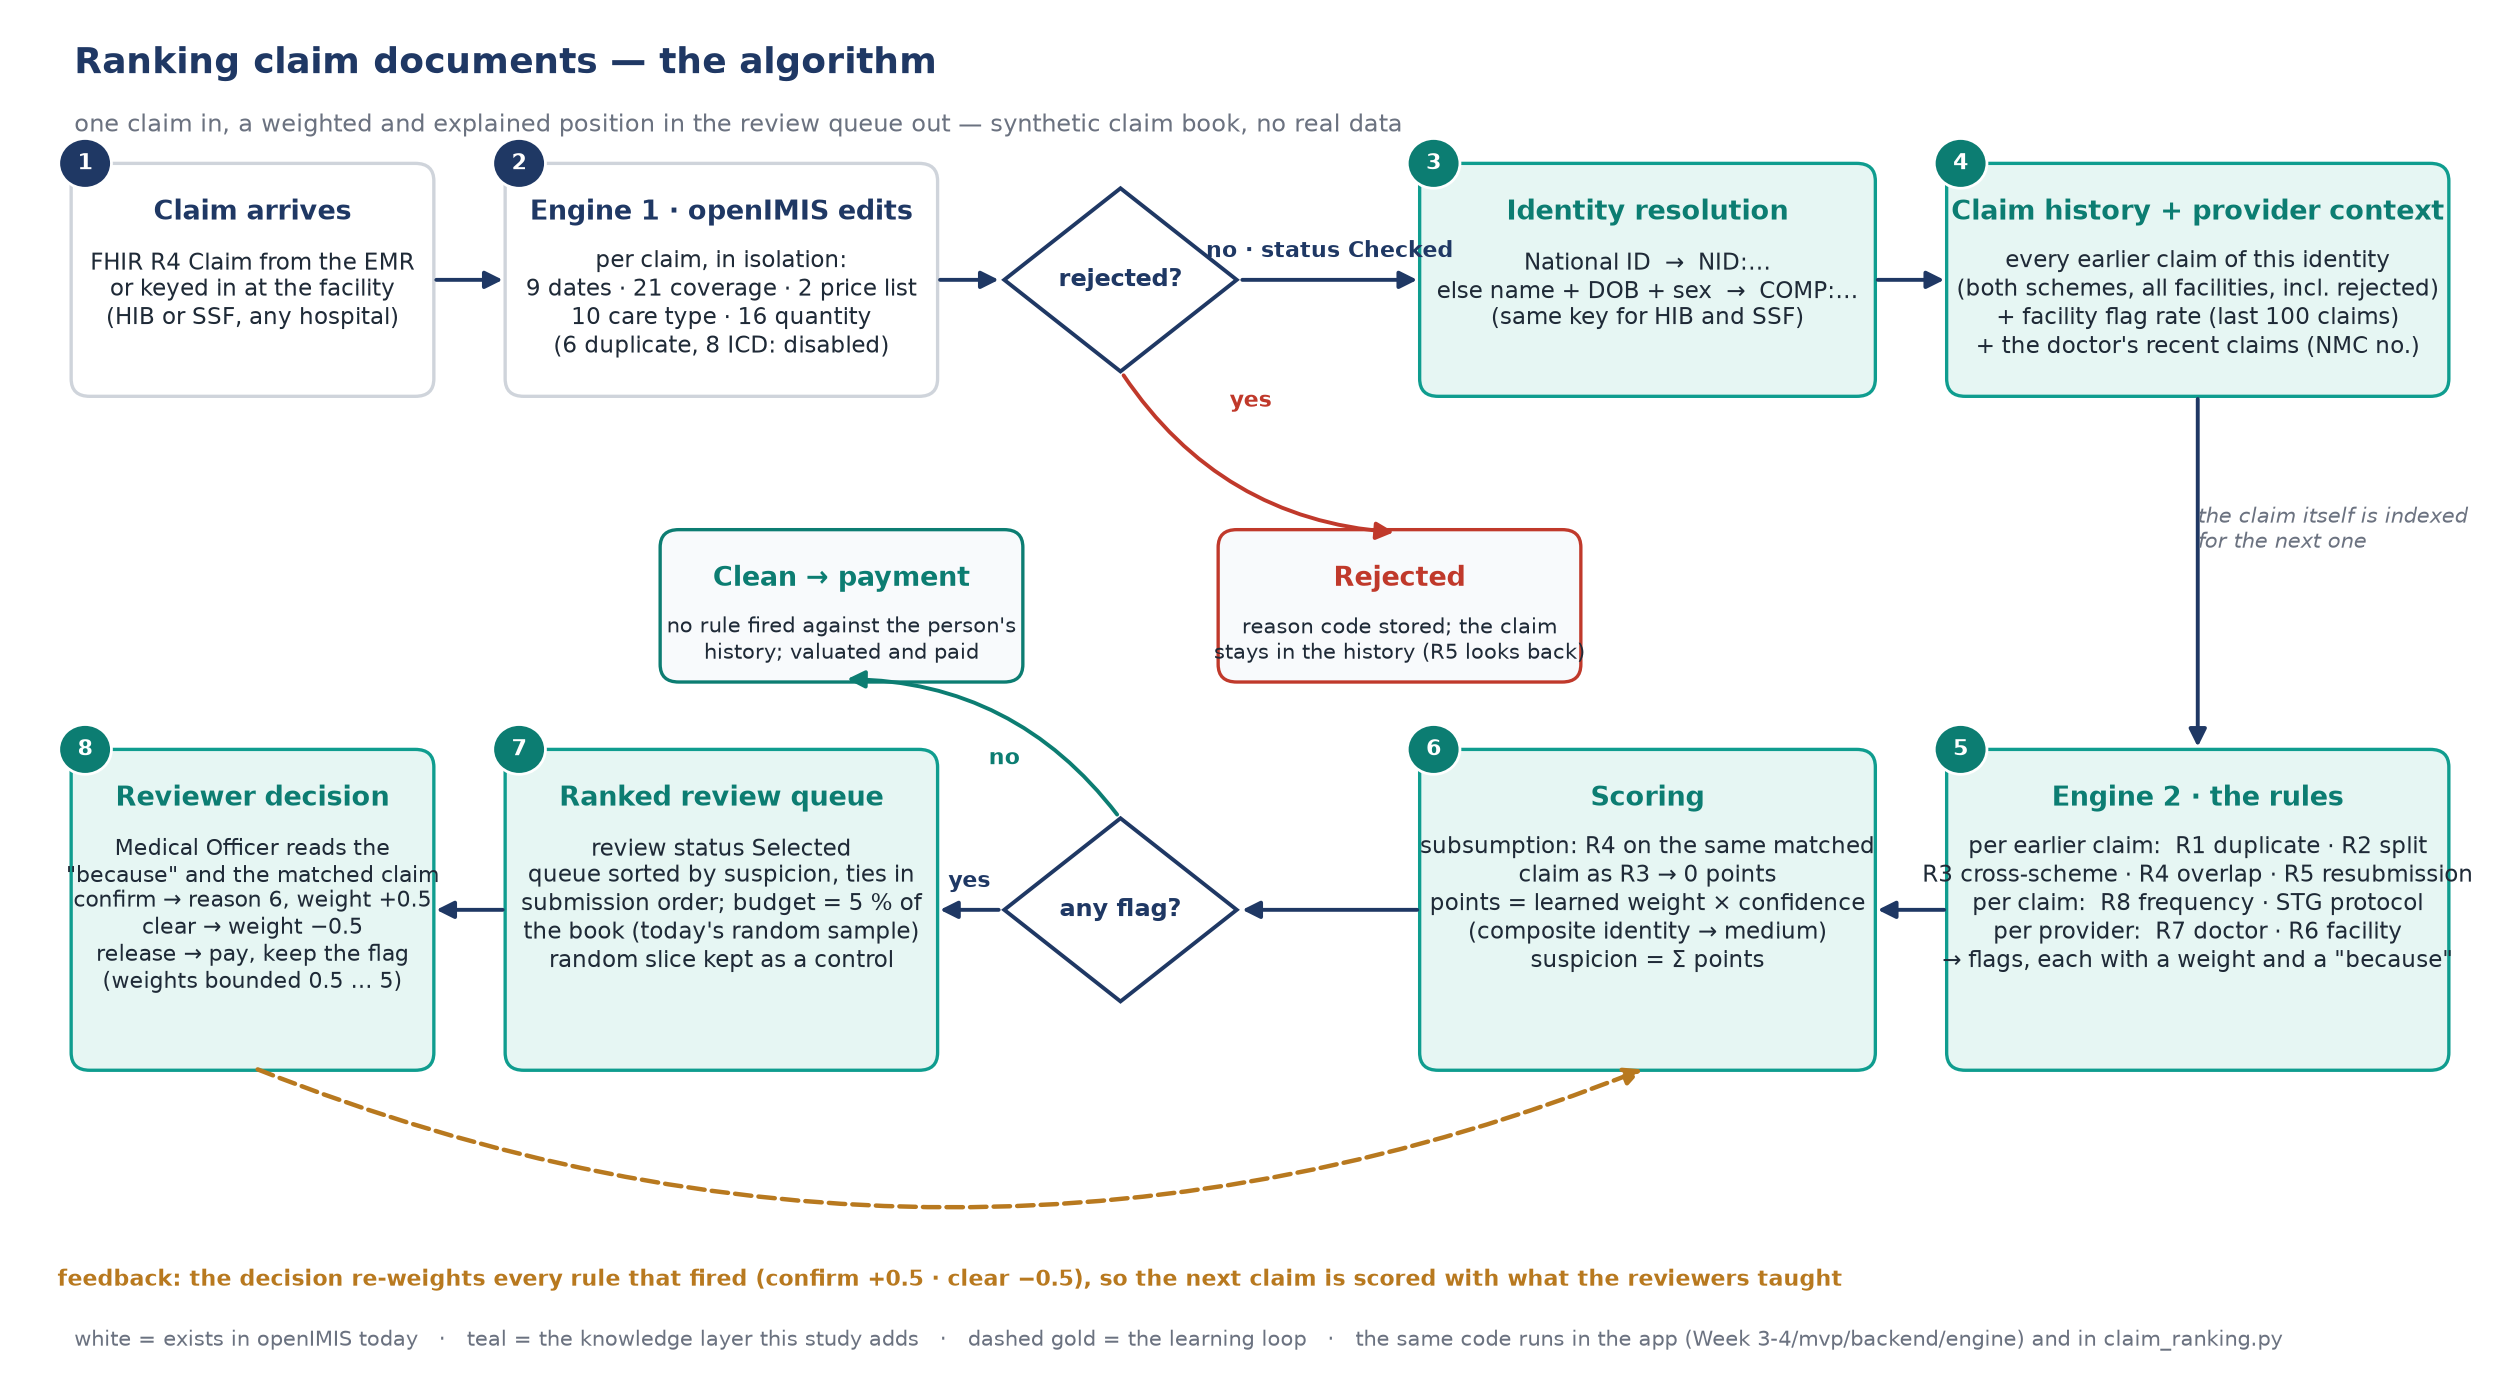

In [5]:
import flowchart
display(Image(flowchart.draw('figures/algorithm_flowchart.png'), width=1100))

### The rule code itself
This is the complete Engine 2 — the function the flowchart's steps 4 and 5 describe. Everything a reviewer sees ("because") is produced here.

In [6]:
print(inspect.getsource(cr.identity_key))
print(inspect.getsource(cr.match_rules))

def identity_key(p: dict) -> dict:
    if p.get('national_id'):
        return {'kind': 'NID', 'key': 'NID:' + p['national_id']}
    norm = ' '.join(str(p.get('name') or '').lower().split())
    return {'kind': 'COMPOSITE', 'key': f"COMP:{norm}|{p.get('dob')}|{p.get('sex')}"}

def match_rules(claim: dict, history: list, ref: dict, ctx: dict | None = None, P: Params = Params()) -> list:
    """Compare the incoming claim with the person's claim HISTORY (across facilities and schemes) and with the
    provider context; return weighted, explained flags. Never rejects.

    history : [{'claim': prior claim, 'verdict': engine-1 verdict}] for the same identity, oldest first
    ref     : {'protocol': {dx: {'allow': set, 'max_los': int, 'ipd': float, 'label': str}}, ...}
    ctx     : {'facility': {'claims', 'flagged', 'medianRate'} | None, 'doctorClaims': [claims with the same NMC no.]}
    """
    ctx = ctx or {}
    flags: list = []

    def flag(rule, matched, because, weight=None):
      

In [7]:
pd.DataFrame([{'rule': r, 'name': v['name'], 'catalog weight': f"{v['weight']} (+{Params().weights[v['weight']]})", 'source': v['source']} for r, v in RULES.items()]).set_index('rule')

,name,catalog weight,source
rule,,,
R1,"Within-scheme duplicate (same day, or identical bill within 14 days)",high (+3),rule catalog R1 · openIMIS reason 6 (disabled) · validation book: re-bills lag 0–14 d
R2,Same-episode split billing (vault),medium (+2),rule catalog R2 · SSF claim vault (facility + contributor + visit date)
R3,Cross-scheme duplicate (HIB ↔ SSF),high (+3),rule catalog R3 · independent ledgers · composite identity → medium
R4,Overlapping inpatient stays (transfer-aware),high (+3),"rule catalog R4 · ""impossible day"" · report: ghost / phantom hospitalisation"
R5,Resubmission gaming (new code after a rejection),medium (+2),rule catalog R5 · edit-gaming attack surface · validation book: honest corrections
STG,"Off-protocol services, over-long stay or unnecessary admission",medium (+2),HIB expert interview: standard treatment protocol · reason 8 (ICD) disabled · report: medical necessity
R6,Provider concentration (facility flag rate far above peers),low (+1),"report: peer benchmarking, PM-JAY provider profiling and de-empanelment"
R7,"One doctor, two facilities, same day",low (+1),"ontology red flag rfSameProviderManyFacilities · report: ghost hospitalisation, duty-hour billing"
R8,Service frequency beyond what the diagnosis warrants,medium (+2),"report: unnecessary tests (HIB 10 % co-payment, Jan 2024) · Taiwan NHI duplicate-service check · HIRA DUR"


## 3 · Run it — and follow one claim through

The engine processes the whole training book in well under a second. Below, the cross-scheme demo case from the app: an appendicitis
admission billed to HIB at one hospital, then billed to SSF at another hospital with overlapping dates.

In [8]:
engines = {k: Engine(d) for k, d in raw.items()}
A = engines['A · training book (seed 42)']; B = engines['B · validation book (seed 2026)']

[engine] 9786 claims processed in 0.2 s · 474 flagged


[engine] 6825 claims processed in 0.1 s · 386 flagged


In [9]:
def show_claim(eng, claim_id):
    c = eng.by_id[claim_id]
    display(Markdown(f"**{c['claim_id']}** · {c['scheme']} · {c['person_name']} ({c['identity']['kind']} key `{c['identity']['key']}`) · {c['hf_name']} · "
                     f"{c['care_type']} {c['date_from']} → {c['date_to']} · dx {c['diagnosis']} · NPR {eng.amount(c):,.0f} · truth: `{c['truth']}` {c['note'] or ''}"))
    print('Engine 1:', c['engine1']['code'], c['engine1']['reason'], '—', c['engine1']['because'])
    print(f"history compared: {c['history_size']} earlier claim(s) of this identity")
    for f in c['flags']:
        print(f"  {f['rule']} [{f['weight']} → {f['points']} pt{' · subsumed by ' + f['subsumedBy'] if f.get('subsumedBy') else ''}] matched {f['matched']}: {f['because']}")
    print(f"suspicion = {c['suspicion']} → routed to {c['routed']}")

# a planted cross-scheme duplicate that R3 caught on the National ID, and the claim it matched
hit = next(c for c in A.claims if c['truth'] == 'cross_scheme' and c['identity']['kind'] == 'NID' and any(f['rule'] == 'R3' for f in c['flags']))
show_claim(A, hit['flags'][0]['matched']); print(); show_claim(A, hit['claim_id'])

**C000380** · HIB · Bikash Raj Mishra (NID key `NID:NID-3374969448`) · Parsa District Hospital · O 2025-09-10 → 2025-09-10 · dx N18 · NPR 3,400 · truth: `legitimate` legitimate repeat treatment (same service, different date)

Engine 1: 0 ACCEPTED — every active edit passed — the claim is CHECKED and moves on
history compared: 2 earlier claim(s) of this identity
suspicion = 0.0 → routed to payment



**C000406** · SSF · Bikash Raj Mishra (NID key `NID:NID-3374969448`) · Parasi District Hospital · O 2025-09-10 → 2025-09-10 · dx N18 · NPR 3,400 · truth: `cross_scheme` same episode reimbursed by the other scheme

Engine 1: 0 ACCEPTED — every active edit passed — the claim is CHECKED and moves on
history compared: 3 earlier claim(s) of this identity
  R3 [high → 3.0 pt] matched C000380: same person (matched on National ID) with the same diagnosis/service within 2 days of C000380, but a DIFFERENT scheme (HIB vs SSF) — neither system sees the other today.
suspicion = 3.0 → routed to review


In [10]:
# the hard case the layer cannot see: no National ID and the name spelt differently at SSF → two identity keys, no history to compare
miss = next(c for c in A.claims if c['truth'] == 'cross_scheme' and (c.get('note') or '').startswith('HARD') and c['engine1']['accepted'] and not c['flags'])
show_claim(A, miss['linked_claim']); print(); show_claim(A, miss['claim_id'])

**C000426** · HIB · Kamala Bishwakarma (COMPOSITE key `COMP:kamala bishwakarma|1993-08-17|F`) · Rautahat District Hospital · I 2025-09-11 → 2025-09-12 · dx K40 · NPR 23,500 · truth: `legitimate` 

Engine 1: 0 ACCEPTED — every active edit passed — the claim is CHECKED and moves on
history compared: 0 earlier claim(s) of this identity
suspicion = 0.0 → routed to payment



**C000446** · SSF · Kamala B.K. (COMPOSITE key `COMP:kamala b.k.|1993-08-17|F`) · Siraha District Hospital · I 2025-09-12 → 2025-09-13 · dx K40 · NPR 23,500 · truth: `cross_scheme` HARD: no NID + name spelling variant -> expected miss

Engine 1: 0 ACCEPTED — every active edit passed — the claim is CHECKED and moves on
history compared: 0 earlier claim(s) of this identity
suspicion = 0.0 → routed to payment


## 4 · What the engine produced

Precision per rule = of the claims a rule flagged, how many were planted frauds. Suspicion separates the two populations:
legitimate claims mostly score 0 (never enter the queue) or 2 (a lone R2 split-billing flag that a reviewer clears); frauds score 2–6.

In [11]:
ev = {k: evaluate(e) for k, e in engines.items()}
summary = pd.DataFrame({k: {'claims': v['claims'], 'planted frauds': v['frauds'], 'flagged': v['flagged'], 'true positives': v['tp'], 'false positives': v['fp'], 'missed': v['fn'],
                            'precision %': round(100 * v['precision'], 1), 'recall %': round(100 * v['recall'], 1),
                            'reviewer budget (5 %)': v['budget'], 'frauds in ranked queue @ budget': v['ranked_frauds'],
                            'frauds in random 5 % sample (mean of 30 draws; the app draws 23 / 13.6 with its own shuffle)': round(v['random']['mean'], 1), '  … range': f"{v['random']['min']}–{v['random']['max']}",
                            'existing engine: rejected': v['existing']['rejected'], 'existing engine: of which fraud': v['existing']['rejected_fraud']} for k, v in ev.items()})
summary

,A · training book (seed 42),B · validation book (seed 2026)
claims,9786,6825
planted frauds,454,261
flagged,474,386
true positives,418,193
false positives,56,193
missed,36,68
precision %,88.2,50.0
recall %,92.1,73.9
reviewer budget (5 %),489,341
frauds in ranked queue @ budget,418,189


In [12]:
# cross-check against the app's own evaluation.json (node evaluate.js)
app = json.load(open(cr.data_path('evaluation'), encoding='utf-8'))
chk = pd.DataFrame([{'book': b['name'], 'app flagged': b['flagged'], 'notebook flagged': v['flagged'], 'app tp': b['tp'], 'notebook tp': v['tp'],
                     'app precision %': round(100 * b['precision'], 1), 'notebook precision %': round(100 * v['precision'], 1)}
                    for b, v in zip(app['books'], ev.values())])
chk

,book,app flagged,notebook flagged,app tp,notebook tp,app precision %,notebook precision %
0,training book,474,474,418,418,88.2,88.2
1,validation book,386,386,193,193,50.0,50.0


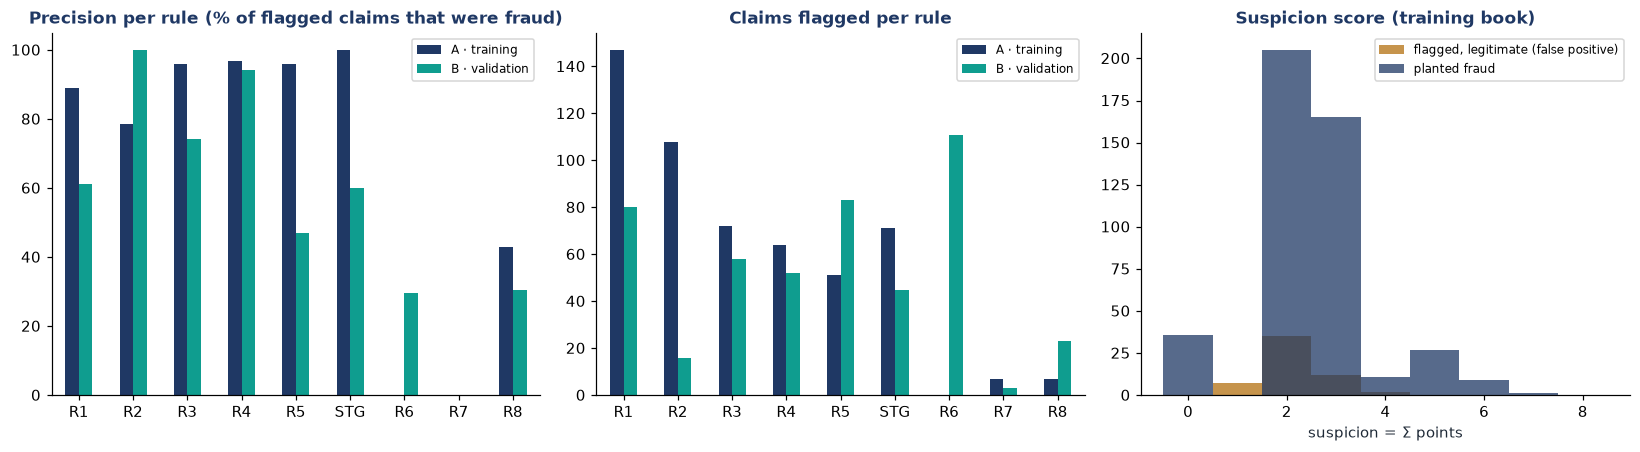

legitimate claims with suspicion 0 (never enter the queue): 9276 of 9332


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
# precision per rule, both books
ax = axes[0]
br = pd.DataFrame({k: {r: 100 * v['by_rule'][r]['fraud'] / v['by_rule'][r]['fired'] for r in v['by_rule']} for k, v in ev.items()}).reindex(list(RULES)).fillna(0)
br.columns = ['A · training', 'B · validation']
br.plot.bar(ax=ax, color=[NAVY, TEAL], rot=0); ax.set_title('Precision per rule (% of flagged claims that were fraud)'); ax.set_ylim(0, 105); ax.legend(fontsize=8)
# fired counts
ax = axes[1]
fc = pd.DataFrame({k: {r: v['by_rule'][r]['fired'] for r in v['by_rule']} for k, v in ev.items()}).reindex(list(RULES)).fillna(0)
fc.columns = ['A · training', 'B · validation']
fc.plot.bar(ax=ax, color=[NAVY, TEAL], rot=0); ax.set_title('Claims flagged per rule'); ax.legend(fontsize=8)
# suspicion distribution
ax = axes[2]
s = pd.DataFrame({'suspicion': [c['suspicion'] for c in A.claims], 'fraud': [is_fraud(c) for c in A.claims], 'flagged': [bool(c['flags']) for c in A.claims]})
bins = np.arange(-0.5, 9.5, 1)
ax.hist(s[s.flagged & ~s.fraud].suspicion, bins=bins, color=GOLD, alpha=.8, label='flagged, legitimate (false positive)')
ax.hist(s[s.fraud].suspicion, bins=bins, color=NAVY, alpha=.75, label='planted fraud')
ax.set_title('Suspicion score (training book)'); ax.set_xlabel('suspicion = Σ points'); ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig('figures/fig_rules.png', dpi=150, bbox_inches='tight'); plt.show()
print('legitimate claims with suspicion 0 (never enter the queue):', int(((~s.fraud) & (s.suspicion == 0)).sum()), 'of', int((~s.fraud).sum()))

In [14]:
# recall by fraud type — the honest table: what each book planted and what the rules caught
bt = pd.concat({k: pd.DataFrame(v['by_type']).T for k, v in ev.items()}, axis=1).fillna(0).astype(int)
for k in ev: bt[(k, 'recall %')] = (100 * bt[(k, 'caught')] / bt[(k, 'planted')].replace(0, np.nan)).round(0)
bt

A · training book (seed 42)        B · validation book (seed 2026)        A · training book (seed 42) B · validation book (seed 2026)
                                                               planted caught                         planted caught                    recall %                        recall %
same_episode                                                        83     83                              20     20                       100.0                           100.0
within_dup                                                         124    124                              38     32                       100.0                            84.0
resubmission                                                        49     49                              42     38                       100.0                            90.0
impossible_overlap                                                  33     31                               0      0                        94.0                             NaN
cross_scheme                                                        70     68                              71     47                        97.0                            66.0
stg_upcode                                                          66     63                              21     21                        95.0                           100.0
cross_scheme (hard: no NID + name variant)                          29      0                               0      0                         0.0                             NaN
phantom_readmission                                                  0      0                              31     31                         NaN                           100.0
upcode_within_protocol                                               0      0                              15      2                         NaN                            13.0
phantom_visit                                                        0      0                              23      2                         NaN                             9.0

## 5 · Ranking: what a reviewer gets for the same budget

Today HIB's Medical Officers review a random 5 % sample. The curve below walks down the ranked queue: after *k* claims, how many frauds
has the reviewer seen? The grey line is the expectation of a random sample (the fraud rate times *k*). The dashed marker is the 5 % budget.

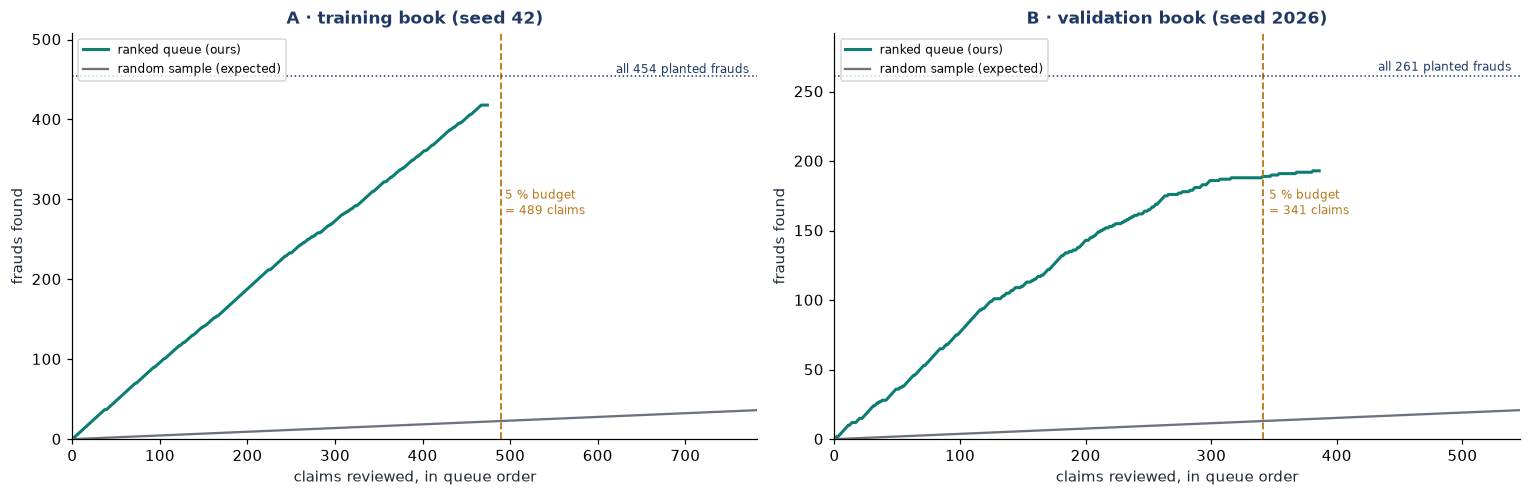

,A · training book (seed 42),B · validation book (seed 2026)
frauds @ 5 % budget — ranked,418,189
frauds @ 5 % budget — random (mean),25.3,13.2
gain,17×,14×
precision in the top 50,96 %,72 %
precision @ budget,88 %,55 %


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, (k, eng) in zip(axes, engines.items()):
    pk = precision_at(eng); v = ev[k]
    ks = [p[0] for p in pk]; hits = [p[1] for p in pk]
    ax.plot(ks, hits, color=TEAL2, lw=2, label='ranked queue (ours)')
    ax.plot([0, v['budget'] * 1.6], [0, v['budget'] * 1.6 * v['fraud_rate']], color=MUTE, lw=1.5, label='random sample (expected)')
    ax.axvline(v['budget'], color=GOLD, ls='--', lw=1.2); ax.text(v['budget'] + 5, v['frauds'] * 0.62, f"5 % budget\n= {v['budget']} claims", color=GOLD, fontsize=8)
    ax.axhline(v['frauds'], color=NAVY, ls=':', lw=1); ax.text(v['budget'] * 1.58, v['frauds'] + 4, f"all {v['frauds']} planted frauds", color=NAVY, fontsize=8, ha='right')
    ax.set_xlim(0, v['budget'] * 1.6); ax.set_ylim(0, v['frauds'] * 1.12)
    ax.set_title(k); ax.set_xlabel('claims reviewed, in queue order'); ax.set_ylabel('frauds found'); ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); fig.savefig('figures/fig_precision_at_k.png', dpi=150, bbox_inches='tight'); plt.show()
pd.DataFrame({k: {'frauds @ 5 % budget — ranked': v['ranked_frauds'], 'frauds @ 5 % budget — random (mean)': round(v['random']['mean'], 1),
                  'gain': f"{v['ranked_frauds'] / v['random']['mean']:.0f}×", 'precision in the top 50': f"{100 * precision_at(engines[k])[49][2]:.0f} %",
                  'precision @ budget': f"{100 * precision_at(engines[k])[min(v['budget'], len(precision_at(engines[k]))) - 1][2]:.0f} %"} for k, v in ev.items()})

In [16]:
# the queue as the reviewer sees it (top of the ranked list, training book) — with the truth column that only synthetic data can show
top = pd.DataFrame([{'claim': c['claim_id'], 'scheme': c['scheme'], 'person': c['person_name'], 'facility': c['hf_name'][:28], 'dates': f"{c['date_from']}→{c['date_to']}",
                     'dx': c['diagnosis'], 'NPR': int(A.amount(c)), 'rules': ' '.join(sorted({f['rule'] for f in c['flags']})), 'suspicion': c['suspicion'], 'truth': c['truth']}
                    for c in A.ranked(15)])
top

,claim,scheme,person,facility,dates,dx,NPR,rules,suspicion,truth
0,C006768,SSF,Nirmala Koirala,Koshi Hospital,2026-05-04→2026-05-04,M54,9000,R3 R5 R8,7.0,resubmission
1,C000345,HIB,Sanu Shakya,Dolpa District Hospital,2025-09-08→2025-09-13,S72,56100,R1 R4,6.0,impossible_overlap
2,C001200,SSF,Chandra Regmi,Nepalgunj Medical College,2025-10-10→2025-10-17,I50,22900,R4,6.0,impossible_overlap
3,C003534,HIB,Grishma Paswan,Syangja District Hospital,2026-01-02→2026-01-03,K40,21800,R1 R4,6.0,impossible_overlap
4,C003866,HIB,Sabina Sunar,Seti Provincial Hospital,2026-01-16→2026-01-17,K40,24000,R1 R4,6.0,impossible_overlap
5,C004451,HIB,Maya Ghimire,Rautahat District Hospital,2026-02-08→2026-02-17,S72,62100,R4,6.0,impossible_overlap
6,C004910,HIB,Bal Nath Limbu,Makwanpur District Hospital,2026-02-25→2026-03-04,S72,58000,R1 R4,6.0,impossible_overlap
7,C005310,HIB,Sushila Maya Bhandari,Kapilvastu District Hospital,2026-03-11→2026-03-13,S06,9100,R1 R4,6.0,impossible_overlap
8,C006032,HIB,Deepak Damai,Hetauda Hospital,2026-04-08→2026-04-14,S72,57100,R1 R4,6.0,impossible_overlap
9,C007964,HIB,Bal Lal Koirala,Salyan District Hospital,2026-06-15→2026-06-23,S72,60600,R1 R4,6.0,impossible_overlap


## 6 · Parameters and sensitivity

Every tunable is a field of `Params`. The sweeps below re-run the whole engine with one parameter changed and report precision / recall
and the frauds reached at the 5 % budget, on both books. The last table drops one rule at a time (ablation): which rules carry the result,
and which are redundant with the others.

In [17]:
def run(params, books=raw):
    out = {}
    for k, d in books.items():
        v = evaluate(Engine(d, params, verbose=False), random_draws=5)
        out[k[:1]] = (round(100 * v['precision'], 1), round(100 * v['recall'], 1), v['ranked_frauds'])
    return out

sweeps = []
for w in [0, 1, 2, 3, 5]:
    r = run(Params(r3_window_days=w)); sweeps.append({'parameter': 'R3 window (days)', 'value': w, **{f'{b} {m}': x for b, t in r.items() for m, x in zip(('precision %', 'recall %', 'frauds @ budget'), t)}})
for w in [0, 7, 14, 21, 30]:
    r = run(Params(r1_near_days=w)); sweeps.append({'parameter': 'R1 identical-bill window (days)', 'value': w, **{f'{b} {m}': x for b, t in r.items() for m, x in zip(('precision %', 'recall %', 'frauds @ budget'), t)}})
for w in [7, 14, 21]:
    r = run(Params(r5_lookback_days=w)); sweeps.append({'parameter': 'R5 look-back (days)', 'value': w, **{f'{b} {m}': x for b, t in r.items() for m, x in zip(('precision %', 'recall %', 'frauds @ budget'), t)}})
for share in [0.02, 0.05, 0.10]:
    r = run(Params(budget_share=share)); sweeps.append({'parameter': 'reviewer budget (share of book)', 'value': share, **{f'{b} {m}': x for b, t in r.items() for m, x in zip(('precision %', 'recall %', 'frauds @ budget'), t)}})
sw = pd.DataFrame(sweeps).set_index(['parameter', 'value']); sw

A precision %  A recall %  A frauds @ budget  B precision %  B recall %  B frauds @ budget
parameter                       value                                                                                            
R3 window (days)                0.00            88.2        87.7                398           49.4        66.7                174
                                1.00            88.7        92.1                418           49.9        71.3                183
                                2.00            88.2        92.1                418           50.0        73.9                189
                                3.00            87.3        92.1                418           51.3        75.5                193
                                5.00            86.5        92.1                418           52.3        78.2                199
R1 identical-bill window (days) 0.00            89.1        92.1                418           53.0        67.4                176
                                7.00            88.4        92.1                418           51.9        73.9                191
                                14.00           88.2        92.1                418           50.0        73.9                189
                                21.00           88.0        92.1                418           49.7        73.9                188
                                30.00           86.9        92.1                418           49.4        73.9                188
R5 look-back (days)             7.00            88.4        92.1                418           50.0        67.8                176
                                14.00           88.2        92.1                418           50.0        73.9                189
                                21.00           88.0        92.1                418           48.2        73.9                188
reviewer budget (share of book) 0.02            88.2        92.1                184           50.0        73.9                105
                                0.05            88.2        92.1                418           50.0        73.9                189
                                0.10            88.2        92.1                418           50.0        73.9                193

In [18]:
# ablation: drop one rule at a time
base = run(Params())
abl = [{'rules': 'all nine (baseline)', **{f'{b} {m}': x for b, t in base.items() for m, x in zip(('precision %', 'recall %', 'frauds @ budget'), t)}}]
for r_off in RULES:
    r = run(Params(enabled=frozenset(set(RULES) - {r_off})))
    abl.append({'rules': f'without {r_off}', **{f'{b} {m}': x for b, t in r.items() for m, x in zip(('precision %', 'recall %', 'frauds @ budget'), t)}})
abl = pd.DataFrame(abl).set_index('rules')
abl['A Δrecall'] = (abl['A recall %'] - abl.loc['all nine (baseline)', 'A recall %']).round(1)
abl['B Δrecall'] = (abl['B recall %'] - abl.loc['all nine (baseline)', 'B recall %']).round(1)
abl

,A precision %,A recall %,A frauds @ budget,B precision %,B recall %,B frauds @ budget,A Δrecall,B Δrecall
rules,,,,,,,,
all nine (baseline),88.2,92.1,418,50.0,73.9,189,0.0,0.0
without R1,88.7,70.7,321,52.5,63.6,166,-21.4,-10.3
without R2,91.2,75.6,343,50.1,70.1,181,-16.5,-3.8
without R3,87.0,78.2,355,50.8,59.8,156,-13.9,-14.1
without R4,87.9,86.8,394,52.5,64.0,167,-5.3,-9.9
without R5,87.3,81.7,371,54.0,62.5,163,-10.4,-11.4
without STG,86.4,78.6,357,53.9,65.9,172,-13.5,-8.0
without R6,88.2,92.1,418,61.6,71.3,186,0.0,-2.6
without R7,89.5,92.1,418,50.4,73.9,189,0.0,0.0


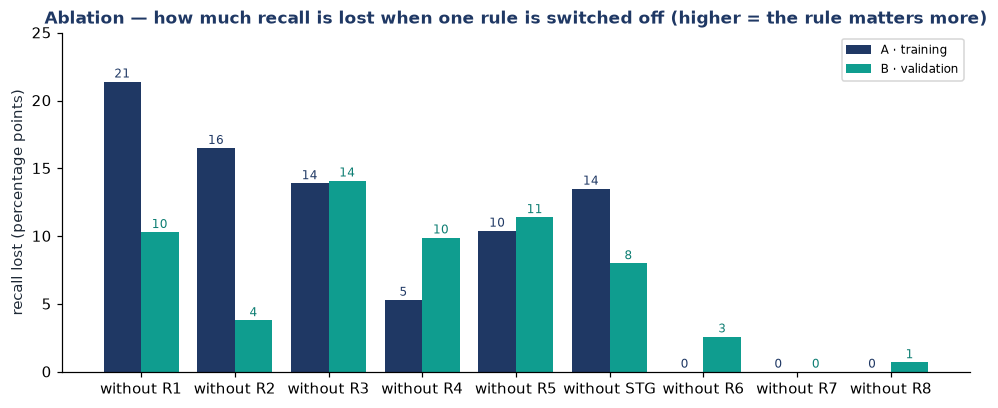

In [19]:
fig, ax = plt.subplots(figsize=(9, 3.8))
d = abl.drop(index='all nine (baseline)')
x = np.arange(len(d)); ax.bar(x - 0.2, -d['A Δrecall'], 0.4, color=NAVY, label='A · training'); ax.bar(x + 0.2, -d['B Δrecall'], 0.4, color=TEAL, label='B · validation')
for xi, (va, vb) in enumerate(zip(-d['A Δrecall'], -d['B Δrecall'])):
    ax.text(xi - 0.2, va + 0.3, f'{abs(va):.0f}', ha='center', fontsize=8, color=NAVY); ax.text(xi + 0.2, vb + 0.3, f'{abs(vb):.0f}', ha='center', fontsize=8, color=TEAL2)
ax.set_xticks(x); ax.set_xticklabels([i.replace('without ', 'without ') for i in d.index]); ax.set_ylabel('recall lost (percentage points)'); ax.set_ylim(0, 25)
ax.set_title('Ablation — how much recall is lost when one rule is switched off (higher = the rule matters more)'); ax.legend(fontsize=8); plt.tight_layout(); fig.savefig('figures/fig_ablation.png', dpi=150, bbox_inches='tight'); plt.show()

## 7 · The learning loop

Reviewer decisions re-weight the rules. Below a Medical Officer works through the top 150 of the ranked queue and decides by the ground truth
(confirm a planted fraud, clear a legitimate claim). The weights move by ±0.5 per decision, bounded 0.5 … 5, and every later claim is scored
with the learned weights. R2, the rule with the most false positives, is the one the reviewers push down.

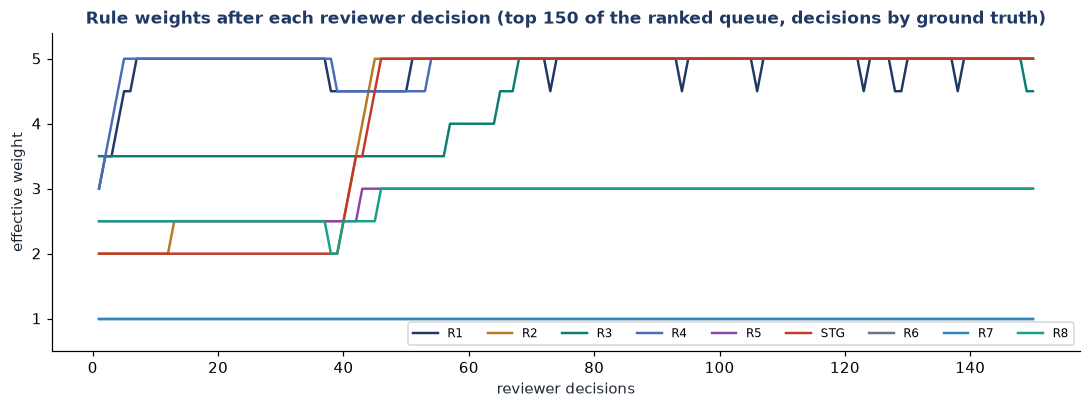

final weights: {'R1': 5.0, 'R2': 5.0, 'R3': 4.5, 'R4': 5.0, 'R5': 3.0, 'STG': 5.0, 'R6': 1, 'R7': 1, 'R8': 3.0}
198 weight changes logged; e.g. {'rule': 'R3', 'from_': 3, 'to': 3.5, 'decision': 'confirm', 'claim_id': 'C006768'}


In [20]:
L = Engine(raw['A · training book (seed 42)'], verbose=False)
trace = []
for i, c in enumerate(L.ranked(150), 1):
    L.review(c['claim_id'], 'confirm' if is_fraud(c) else 'clear')
    trace.append({'decision': i, **L.rule_weight})
tr = pd.DataFrame(trace).set_index('decision')
fig, ax = plt.subplots(figsize=(10, 3.8))
for r, col in zip(RULES, [NAVY, GOLD, TEAL2, '#4b6cb7', '#8e44ad', RED, MUTE, '#2e86c1', '#16a085']):
    ax.plot(tr.index, tr[r], label=r, color=col, lw=1.6)
ax.set_title('Rule weights after each reviewer decision (top 150 of the ranked queue, decisions by ground truth)')
ax.set_xlabel('reviewer decisions'); ax.set_ylabel('effective weight'); ax.legend(ncol=9, fontsize=8, loc='lower right'); ax.set_ylim(0.5, 5.4); plt.tight_layout(); fig.savefig('figures/fig_weights.png', dpi=150, bbox_inches='tight'); plt.show()
print('final weights:', L.rule_weight)
print(f'{len(L.weight_log)} weight changes logged; e.g.', L.weight_log[0])

## 8 · Honest evaluation: two books, two answers

The training book was written by the same team as the rules, so its fraud injection is close to the rules written backwards; the numbers there
measure how well the rules hit their own targets. The validation book simulates *behaviour* (lags drawn from distributions, fraud concentrated in a few
facilities and dual-enrolled patients, fraud types the rules do not target, honest confounders such as transfers, homonyms and follow-ups) and the engine
ran on it unchanged. Precision halves and recall drops to about three quarters — and that is the number to quote.

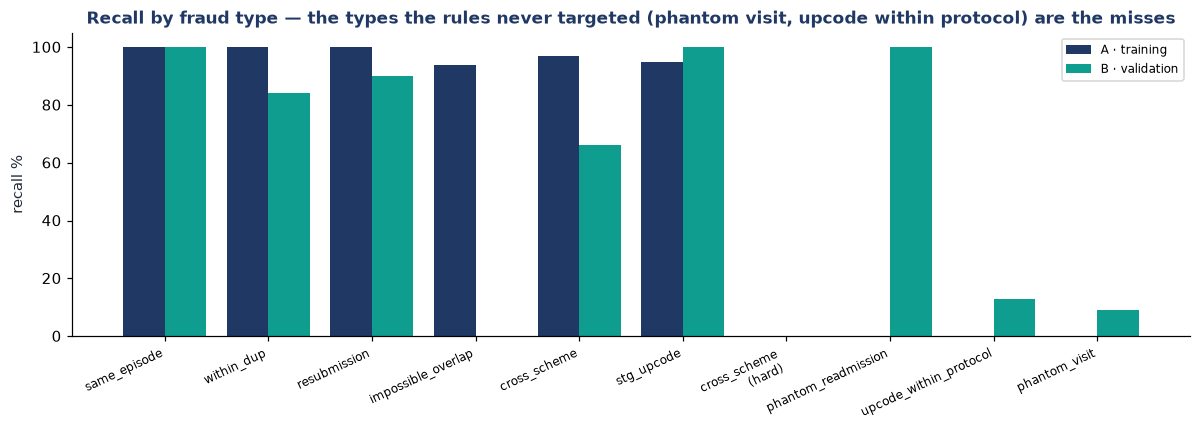

In [21]:
fig, ax = plt.subplots(figsize=(11, 4))
lab = [t for t in bt.index]
x = np.arange(len(lab))
ax.bar(x - 0.2, bt[('A · training book (seed 42)', 'recall %')].fillna(0), 0.4, color=NAVY, label='A · training')
ax.bar(x + 0.2, bt[('B · validation book (seed 2026)', 'recall %')].fillna(0), 0.4, color=TEAL, label='B · validation')
ax.set_xticks(x); ax.set_xticklabels([l.replace(' (hard: no NID + name variant)', '\n(hard)') for l in lab], rotation=25, ha='right', fontsize=8)
ax.set_ylabel('recall %'); ax.set_title('Recall by fraud type — the types the rules never targeted (phantom visit, upcode within protocol) are the misses'); ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig('figures/fig_recall_by_type.png', dpi=150, bbox_inches='tight'); plt.show()

## 9 · Export for the deck and the web app

Everything above that the slides and the app quote is written to `figures/results.json` (numbers, sweeps, ablation, weights) next to the PNG figures,
so the three stay in sync: change a rule here, re-run, copy the folder.

In [22]:
def book_summary(k, v):
    pk = precision_at(engines[k])
    return {'name': k, 'claims': v['claims'], 'persons': v['persons'], 'frauds': v['frauds'], 'fraud_rate': round(v['fraud_rate'], 4), 'flagged': v['flagged'], 'tp': v['tp'], 'fp': v['fp'], 'fn': v['fn'],
            'precision': round(v['precision'], 4), 'recall': round(v['recall'], 4), 'budget': v['budget'], 'ranked_frauds': v['ranked_frauds'],
            'random_mean': round(v['random']['mean'], 1), 'random_min': v['random']['min'], 'random_max': v['random']['max'],
            'precision_top50': round(pk[49][2], 3), 'precision_at_budget': round(pk[min(v['budget'], len(pk)) - 1][2], 3),
            'existing_rejected': v['existing']['rejected'], 'existing_rejected_fraud': v['existing']['rejected_fraud'],
            'by_rule': v['by_rule'], 'by_type': v['by_type']}
results = {
    'generated_at': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M'), 'note': 'All claims synthetic. Produced by claim_ranking.ipynb (Week 5/ranking_notebook); numbers identical to the app engine.',
    'rules': {r: {'name': v['name'], 'weight': v['weight'], 'points': Params().weights[v['weight']], 'source': v['source']} for r, v in RULES.items()},
    'params': {k: (sorted(v) if isinstance(v, (set, frozenset)) else v) for k, v in Params().__dict__.items()},
    'books': {k[:1]: book_summary(k, v) for k, v in ev.items()},
    'sweeps': [{'parameter': p, 'value': float(val), **{c: (None if pd.isna(x) else float(x)) for c, x in row.items()}} for (p, val), row in sw.iterrows()],
    'ablation': [{'rules': r, **{c: float(x) for c, x in row.items()}} for r, row in abl.iterrows()],
    'learning': {'decisions': int(len(tr)), 'final_weights': {k: float(v) for k, v in L.rule_weight.items()}, 'changes_logged': len(L.weight_log)},
    'precision_at_k': {k[:1]: [[i, h] for i, h, _ in precision_at(e)][::5] for k, e in engines.items()},
    'figures': ['fig_dataset.png', 'fig_rules.png', 'fig_precision_at_k.png', 'fig_ablation.png', 'fig_weights.png', 'fig_recall_by_type.png', 'algorithm_flowchart.png'],
}
json.dump(results, open('figures/results.json', 'w', encoding='utf-8'), indent=1, ensure_ascii=False)
print('wrote figures/results.json;', {k: (v['precision'], v['recall'], v['ranked_frauds']) for k, v in results['books'].items()})

wrote figures/results.json; {'A': (0.8819, 0.9207, 418), 'B': (0.5, 0.7395, 189)}


## Reproduce, change, extend

* `python claim_ranking.py` prints the headline numbers for both books; `python flowchart.py` redraws the flowchart.
* Change a threshold or a weight in `Params(...)` and re-run section 6; add a rule inside `match_rules` (and a row in `RULES`) and every table above picks it up.
* The same rules run in the web app (`Week 3-4/mvp`, hosted at https://rijan7ghimire.github.io/Openimis-Claimadj/); the app adds the reviewer UI, the provider view and the FHIR/openIMIS timeline.
* To regenerate the books: `python nepal_synthetic_claims.py --seed 42` and `python nepal_validation_book.py --seed 2026` in `Week 3-4/synthetic_data/`.

*Synthetic data throughout. Sources for the rules: Week 2 rule catalog; HIB expert interview (2025); health-insurance claim adjudication report with references (2025); openIMIS `claim/validations.py`.*